In [89]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import PyMuPDFLoader
from dotenv import load_dotenv
load_dotenv()

True

In [90]:
model=ChatOpenAI(model='gpt-5-mini')

In [91]:
loader=PyMuPDFLoader("D:\Volume C\Downloads\GenAI resume test.pdf")
docs=loader.load()
docs

[Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2026-08-12T17:29:56+00:00', 'source': 'D:\\Volume C\\Downloads\\GenAI resume test.pdf', 'file_path': 'D:\\Volume C\\Downloads\\GenAI resume test.pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'resume (2).pdf', 'author': 'TANISHK GAMING', 'subject': '', 'keywords': 'DAHA1eogwRA,BAEaO8hir0A', 'moddate': '2026-08-12T17:29:56+00:00', 'trapped': '', 'modDate': "D:20260812172956+00'00'", 'creationDate': "D:20260812172956+00'00'", 'page': 0}, page_content='DCRUST University \nB.Tech in Computer Science  – CGPA: 7.12/10 \nSonipat, Haryana\n2023 – 2027\nEducation \nGenerative AI & LLMs: LangChain,  AI Agents, RAG, Prompt Engineering, LLM Applications, LangSmith, RAGAS\nAI / Machine Learning: Python, TensorFlow, Scikit-learn, ANN, CNN, LSTM, Transfer Learning, Computer Vision, NLP,\nSentiment Analysis, Text Preprocessing, Word Embeddings, Semantic Search\nData & Programming Fundamentals: SQL, Data Structures & A

In [92]:
class resumestate(TypedDict):
    resume_text:str
    jd:str
    skills:str
    exp:str
    education:str
    ATS:float
    overall_feedback:str

In [93]:
class schema(BaseModel):
    feedback:str=Field(description='returns the feedback')

str_model=model.with_structured_output(schema)

In [94]:
#Skills Match
def eval_skills(state: resumestate) -> resumestate:
    resume=state['resume_text']
    jd=state['jd']
    prompt=f'you are an helpful assistant, which checks and evaluate the resume based on jd and dont question back and only generate the feedback only.this is the candidates resume: {resume} and and this is our jd:{jd}, so evaluate skill match this resume based on our jd and evaluate and generate feedback based on skills'
    rs=str_model.invoke(prompt)
    return {'skills':rs.feedback}

In [95]:
#Experience
def eval_exp(state: resumestate) -> resumestate:
    resume=state['resume_text']
    jd=state['jd']
    prompt=f'you are an helpful assistant, which checks and evaluate the resume based on jd and dont question back and only generate the feedback only.this is the candidates resume: {resume} and and this is our jd:{jd}, so evaluate experience match this resume based on our jd and evaluate and generate feedback based on experience'
    rs=str_model.invoke(prompt)
    return {'exp':rs.feedback}


In [96]:
def eval_education(state: resumestate) -> resumestate:
    resume=state['resume_text']
    jd=state['jd']
    prompt=f'you are an helpful assistant, which checks and evaluate the resume based on jd and dont question back and only generate the feedback only.this is the candidates resume: {resume} and and this is our jd:{jd}, so evaluate education match this resume based on our jd and evaluate and generate feedback based on education.'
    rs=str_model.invoke(prompt)
    return {'education':rs.feedback}

In [97]:
def eval_ats(state:resumestate) -> resumestate:
    resume=state['resume_text']
    jd=state['jd']
    prompt=f'you are an helpful ATS assistant, which checks and evaluate the resume based on jd and dont question back and only generate the feedback only.this is the candidates resume: {resume} and and this is our jd:{jd}, so evaluate and calculate ATS score for this resume based on our jd and evaluate and generate feedback based on ATS score only, no other and useless content'
    rs=str_model.invoke(prompt)
    return {'ATS':rs.feedback}

In [98]:
def final_eval(state: resumestate) -> resumestate:
    ats=state['ATS']
    skill=state['skills']
    exp=state['exp']
    edu=state['education']
    prompt=f'you are an helpful assistant, and you evaluate and summarize feedback on different aspects and also provide ATS score in response: {ats}, experience: {exp}, education: {edu}, skills: {skill}'
    rs=model.invoke(prompt)
    state['overall_feedback']=rs.content
    return state

In [99]:
graph=StateGraph(resumestate)

graph.add_node('eval_skills', eval_skills)
graph.add_node('eval_exp', eval_exp)
graph.add_node('eval_education', eval_education)
graph.add_node('eval_ats', eval_ats)
graph.add_node('final_eval', final_eval)

graph.add_edge(START, 'eval_skills')
graph.add_edge(START, 'eval_exp')
graph.add_edge(START, 'eval_education')
graph.add_edge(START, 'eval_ats')

graph.add_edge('eval_skills', 'final_eval')
graph.add_edge('eval_exp', 'final_eval')
graph.add_edge('eval_education', 'final_eval')
graph.add_edge('eval_ats', 'final_eval')

graph.add_edge('final_eval', END)

wf=graph.compile()


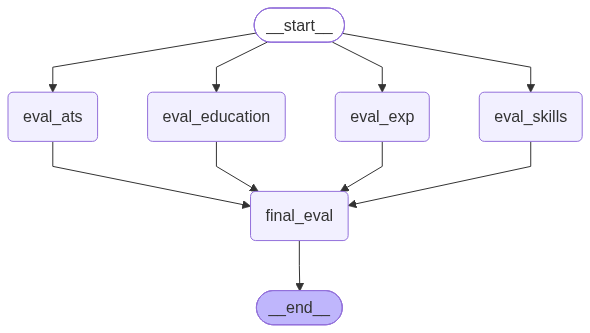

In [100]:
wf

In [101]:
jd="We're looking for an entry-level Machine Learning Engineer with a focus on LLMs and AI agents for Gabeo.ai, a Bay Area health-tech startup working on AI solutions for healthcare revenue cycle management, particularly denied medical claims. The ideal candidate should have experience with AI Agent frameworks such as LangChain, LangGraph, AutoGen, CrewAI, Auto-GPT, or custom-built agent systems, along with knowledge of multi-agent coordination, autonomous task execution, memory management, and tool-based reasoning using LLMs. The role involves developing and optimizing ML models and AI agents, working with claim data, preprocessing and feature engineering, researching new AI/ML techniques, integrating models into production, and monitoring model performance. Candidates should have a Bachelor's or Master's degree in Computer Science, Machine Learning, Data Science, or a related field, along with Python, TensorFlow or PyTorch, NLP, LLM, and transformer knowledge. The company values innovation, collaboration, problem-solving, and an interest in applying AI to real-world healthcare problems."

In [102]:
resume="""'DCRUST University \nB.Tech in Computer Science  – CGPA: 7.12/10 \nSonipat, Haryana\n2023 – 2027\nEducation \nGenerative AI & LLMs: LangChain,  AI Agents, RAG, Prompt Engineering, LLM Applications, LangSmith, RAGAS\nAI / Machine Learning: Python, TensorFlow, Scikit-learn, ANN, CNN, LSTM, Transfer Learning, Computer Vision, NLP,\nSentiment Analysis, Text Preprocessing, Word Embeddings, Semantic Search\nData & Programming Fundamentals: SQL, Data Structures & Algorithms, OOP, C, C++, Java\nTools & Platforms: Git, GitHub, Jupyter Notebook, Google Colab, VS Code\nTechnical Skills\n \nProjects\n- Built a RAG application to help students learn from uploaded books and notes through context-aware question answering.\n- Implemented document chunking, vector embeddings, semantic search, and retrieval using FAISS and Gemini API.\n- Enables personalized, hallucination-reduced learning by generating answers grounded in the uploaded study material.\nSyllabix - AI Study Companion | LangChain, Gemini API, FAISS, Streamlit\nYouTube RAG Chatbot | LangChain, Gemini, Huggingface, Chroma\n- Developed a RAG-powered chatbot that allows users to interact with YT videos by asking questions.\n- Built an end-to-end pipeline using transcript extraction, embeddings, vector search, and LLM response generation.\n- Helps users quickly retrieve key concepts and save time while learning from educational video content\nCompany Policy RAG & Evaluation | Python, LangChain, OpenAI, Gemini API, FAISS, RAGAS\n- Built a RAG assistant to answer employee queries from company policy documents with context-aware responses.\n- Implemented semantic retrieval and assessed RAG performance using RAGAS evaluation metrics.\nIMDb Sentiment Analysis | Python, NLP, TensorFlow, Scikit-learn\n- Developed a sentiment classification model using the IMDb dataset containing 50,000+ movie reviews.\n- Applied text preprocessing, tokenization, sequence padding, and word embeddings.\n- Classified reviews as positive or negative using deep learning-based NLP techniques.\nNext Word Predictor | Python, TensorFlow, LSTM, NLP\n- Built an NLP model using LSTM networks to predict the next word in a sentence.\n- Implemented text preprocessing, tokenization, sequence padding, and word embeddings.\n- Generated context-aware predictions by learning sequential patterns from text data.\n \nLeadership & Achievements\n- Coordinating college-level events and student initiatives, improving participation and engagement\n- Collaborating with teams to plan and execute large-scale academic and technical events\nVice President — Student Council\n- Launched and organized a structured AI/ML GVAC cohort, conducting weekly classes and hands-on workshops.\n- Mentored students in machine learning fundamentals and guided them on practical AI/ML projects.\nVice President — AI/ML Club\n- Organized HackSwitch (6-hour hackathon), managing planning, execution, and participant coordination\n- Delivered an AI Tools workshop as speaker, introducing practical AI applications\n- Led an AI tools workshop for international (Nepal) delegation\n- Conducted a Web Development workshop as Speaker for juniors on HTML, CSS, and JavaScript\nTechnical Activities:\nCertifications:\n- Machine Learning Foundations — Amazon Web Services\n- ML Foundations: Calculus/Statistics — LinkedIn Learning\nAspiring AI Engineer with hands-on experience building intelligent applications using Machine Learning, Deep Learning, and\nLarge Language Models. Developed AI projects across Computer Vision, NLP, Recommendation Systems, and Retrieval-Augmented\nGeneration (RAG) using Python, TensorFlow, LangChain, and LangGraph. Passionate about building real-world AI systems and\ncontributing to practical AI solutions through continuous learning and community leadership."""

In [ ]:
rs=wf.invoke({'resume_text':resume, 'jd':jd})


{'resume_text': "'DCRUST University \nB.Tech in Computer Science  – CGPA: 7.12/10 \nSonipat, Haryana\n2023 – 2027\nEducation \nGenerative AI & LLMs: LangChain,  AI Agents, RAG, Prompt Engineering, LLM Applications, LangSmith, RAGAS\nAI / Machine Learning: Python, TensorFlow, Scikit-learn, ANN, CNN, LSTM, Transfer Learning, Computer Vision, NLP,\nSentiment Analysis, Text Preprocessing, Word Embeddings, Semantic Search\nData & Programming Fundamentals: SQL, Data Structures & Algorithms, OOP, C, C++, Java\nTools & Platforms: Git, GitHub, Jupyter Notebook, Google Colab, VS Code\nTechnical Skills\n \nProjects\n- Built a RAG application to help students learn from uploaded books and notes through context-aware question answering.\n- Implemented document chunking, vector embeddings, semantic search, and retrieval using FAISS and Gemini API.\n- Enables personalized, hallucination-reduced learning by generating answers grounded in the uploaded study material.\nSyllabix - AI Study Companion | La

In [104]:
rs['overall_feedback']

'ATS Score: 70 / 100\n\nConcise summary\n- Overall: Strong candidate for LLM/RAG-focused entry-level roles due to hands-on RAG projects, LangChain experience, embeddings/FAISS work, and core ML/NLP skills. Missing domain-specific healthcare/claims experience, broader multi-agent framework exposure, explicit multi-agent coordination/memory/tool-use examples, PyTorch/fine-tuning evidence, and clear production/MLOps experience — these gaps reduce immediate fit for Gabeo.ai’s denied-claims agent role.\n- To become a top candidate (target ~85%+), focus on a small set of high-impact additions: a claims-focused RAG/agent demo, multi-agent coordination project using another agent framework (AutoGen/LangGraph/CrewAI/Auto-GPT), and one productionized deployment with monitoring.\n\nStrengths (what raised the score)\n- Direct, hands-on RAG and retrieval experience (LangChain, embeddings, FAISS/Chroma, semantic search).\n- Practical projects showing end-to-end pipelines (document chunking, RAGAS ev